# Gradient Descent on House Prices Dataset


Model Performance:
Mean Squared Error: 0.5023642289784899
Mean Absolute Error: 0.519094319027634
R2 Score: 0.6529242642153175
Coefficients (scaled):
  area                                +0.2738
  bedrooms                            +0.0303
  bathrooms                           +0.2940
  stories                             +0.1890
  mainroad                            +0.0686
  guestroom                           +0.0474
  basement                            +0.0996
  hotwaterheating                     +0.0766
  airconditioning                     +0.1968
  parking                             +0.1036
  prefarea                            +0.1429
  furnishingstatus_semi-furnished     -0.0335
  furnishingstatus_unfurnished        -0.1038


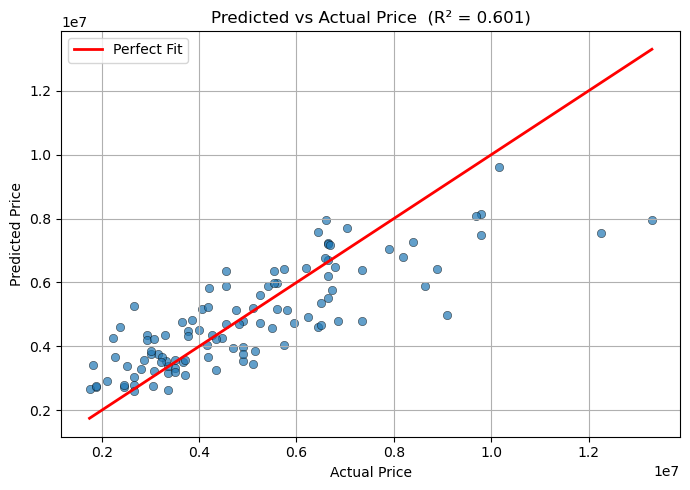

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


df = pd.read_csv("Housing.csv")

binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})

df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)


feature_cols = [
    "area", "bedrooms", "bathrooms", "stories",
    "mainroad", "guestroom", "basement", "hotwaterheating",
    "airconditioning", "parking", "prefarea",
    "furnishingstatus_semi-furnished", "furnishingstatus_unfurnished"
]

X = df[feature_cols]
y = df["price"]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_actual = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()


print("\nModel Performance:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


print("Coefficients (scaled):")
for feat, coef in zip(feature_cols, model.coef_):
    print(f"  {feat:<35} {coef:+.4f}")



plt.figure(figsize=(7, 5))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.7, edgecolors="k", linewidths=0.4)
min_val = min(y_test_actual.min(), y_pred_actual.min())
max_val = max(y_test_actual.max(), y_pred_actual.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, label="Perfect Fit")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual Price  (R² = {r2:.3f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




Final Parameters:
m (slope): 0.5359973448760139
b (intercept): 2.7743760398119064e-16


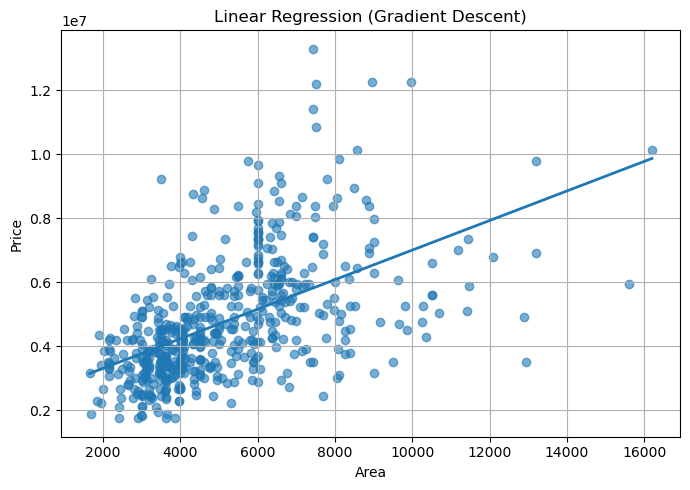

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

df = pd.read_csv("Housing.csv")
df = df.dropna()

X = df[["area"]].values
y = df[["price"]].values


scaler_minmax_X = MinMaxScaler()
scaler_minmax_y = MinMaxScaler()

X_normalized = scaler_minmax_X.fit_transform(X)
y_normalized = scaler_minmax_y.fit_transform(y)

scaler_std_X = StandardScaler()
scaler_std_y = StandardScaler()

X_scaled = scaler_std_X.fit_transform(X)
y_scaled = scaler_std_y.fit_transform(y)

m = 0.0
b = 0.0

learning_rate = 0.01
iters = 1000
n = len(X_scaled)
loss_list = []

for i in range(iters):
    y_pred = m * X_scaled + b
    error = y_pred - y_scaled
    loss = np.mean(error ** 2)
    loss_list.append(loss)
    dm = (2/n) * np.sum(error * X_scaled)
    db = (2/n) * np.sum(error)
    m = m - learning_rate * dm
    b = b - learning_rate * db

print("Final Parameters:")
print("m (slope):", m)
print("b (intercept):", b)

y_pred_scaled = m * X_scaled + b
y_pred_actual = scaler_std_y.inverse_transform(y_pred_scaled)
y_actual = scaler_std_y.inverse_transform(y_scaled)


plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.6)
sorted_idx = np.argsort(X.flatten())
plt.plot(X[sorted_idx], y_pred_actual[sorted_idx], linewidth=2)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Linear Regression (Gradient Descent)")
plt.grid(True)
plt.tight_layout()
plt.show()

